# 🚢 Challenge #01: Titanic — From Scratch

**Authors:** Zakariae

**Date:**  thursday 05/03/2026
**Time Limit:** 5 hours 

**Rules:** No scikit-learn for model building. Only NumPy, Pandas, Matplotlib.

## Step 0: Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Load and shuffle data (shuffling prevents bias if data is sorted by class/name)
df = pd.read_csv("data/train.csv")
df = df.set_index('PassengerId')
df = df.sample(frac=1, random_state=42)

print(f"Shape: {df.shape}")
df.head()

Shape: (891, 11)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


## Step 1: Problem Framing (30 min) ⏱️

**What am I predicting?**  
- It s a "Binary classification" the "Survived" column , based on people infos i have to predict if they will survive or not.
**What metric defines success?**  
- "accuracy" and "F1-Score" because we have an embalenced data (38% vs 62%)
**Business context:**
- "Understanding which passenger characteristics predicted survival" can inform evacuation protocols and safety priorities

## Step 2: EDA (45 min) ⏱️

In [3]:
# Target distribution
n_total = len(df)
n_survived = df['Survived'].sum()
n_died = n_total - n_survived

print(f"Survived:      {n_survived:>4} | {n_survived/n_total:.1%}")
print(f"Didn't survive:{n_died:>4} | {n_died/n_total:.1%}")
print(f"\nNot too imbalanced — accuracy is usable, but F1 is still a good complement.")

Survived:       342 | 38.4%
Didn't survive: 549 | 61.6%

Not too imbalanced — accuracy is usable, but F1 is still a good complement.


In [4]:
# Data types and missing values
df.info()

<class 'pandas.DataFrame'>
Index: 891 entries, 710 to 103
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 83.5 KB


In [5]:
# Numerical summary
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


👨   Male: Survived 109/577 (18.9%)
👩 Female: Survived 233/314 (74.2%)


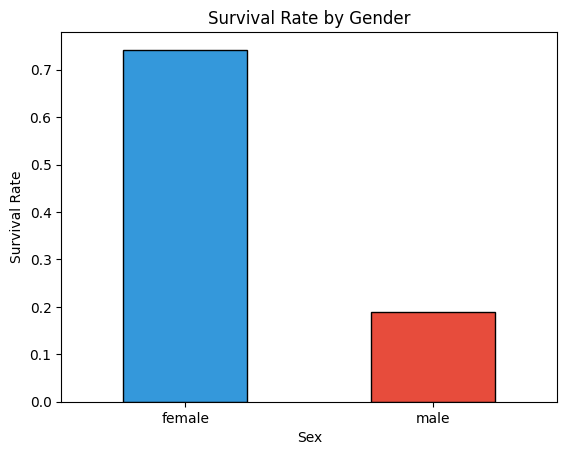

In [6]:
# Survival rate by gender
for sex in ['male', 'female']:
    total = df[df['Sex'] == sex].shape[0]
    survived = df[(df['Survived'] == 1) & (df['Sex'] == sex)].shape[0]
    emoji = '👨' if sex == 'male' else '👩'
    print(f"{emoji} {sex.capitalize():>6}: Survived {survived}/{total} ({survived/total:.1%})")

df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='black')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

Class 1: Survived 136/216 (63.0%)
Class 2: Survived 87/184 (47.3%)
Class 3: Survived 119/491 (24.2%)


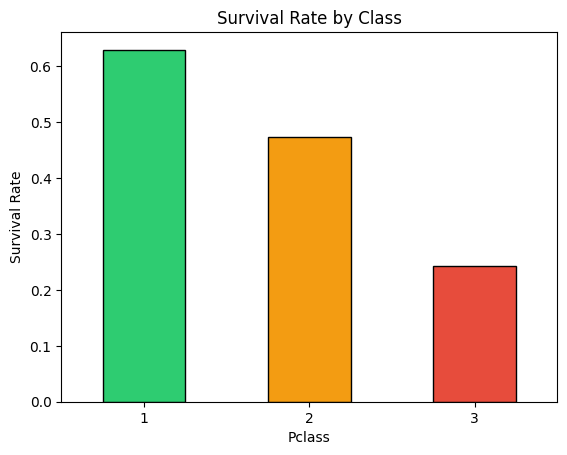

In [7]:
# Survival rate by class
for pclass in [1, 2, 3]:
    total = df[df['Pclass'] == pclass].shape[0]
    survived = df[(df['Survived'] == 1) & (df['Pclass'] == pclass)].shape[0]
    print(f"Class {pclass}: Survived {survived}/{total} ({survived/total:.1%})")

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
plt.title('Survival Rate by Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

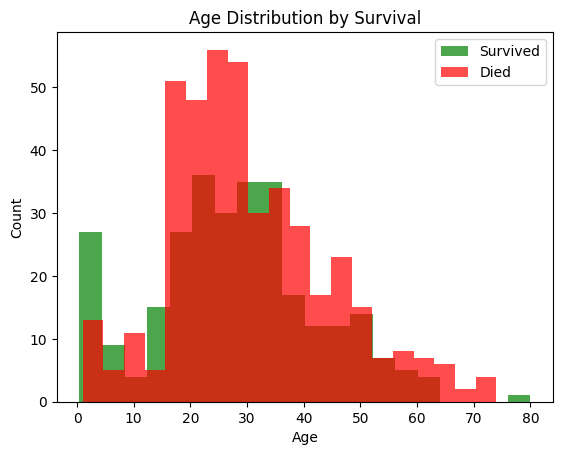

In [8]:
# Age distribution: survived vs died
df[df['Survived'] == 1]['Age'].plot(kind='hist', bins=20, alpha=0.7, label='Survived', color='green')
df[df['Survived'] == 0]['Age'].plot(kind='hist', bins=20, alpha=0.7, label='Died', color='red')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

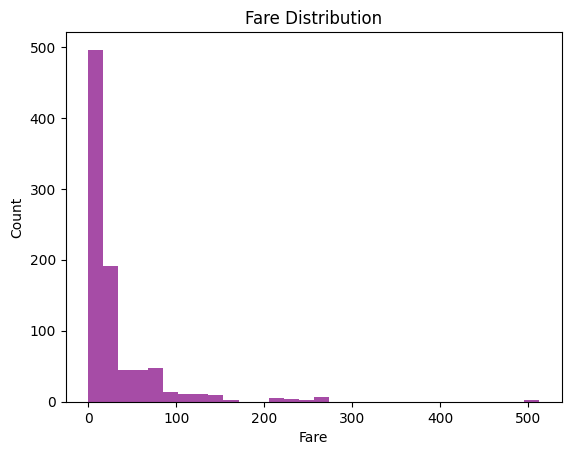

In [9]:
# Fare distribution
df['Fare'].plot(kind='hist', bins=30, color='purple', alpha=0.7)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

In [10]:
# Missing values summary
print("Missing values:")
print(df.isnull().sum())
print(f"\nAge:      {df['Age'].isnull().sum()} missing ({df['Age'].isnull().mean():.1%})")
print(f"Cabin:    {df['Cabin'].isnull().sum()} missing ({df['Cabin'].isnull().mean():.1%}) → will drop this column")
print(f"Embarked: {df['Embarked'].isnull().sum()} missing → will drop these 2 rows")

Missing values:
Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

Age:      177 missing (19.9%)
Cabin:    687 missing (77.1%) → will drop this column
Embarked: 2 missing → will drop these 2 rows


### Initial Hypotheses
1. females have more chance to survive
2. higher class means higher chance to survive
3. teenagers and new-born babies have more chance to survive

So a group of people have the chance to escape but they can't all do it.
They choose teens that have more power to survive, along with females (gentlemen haha), and some prefer their babies to inherit from them. And of course, the higher class people with strong 3rd class believers win!

This shit sounds racist hhhhhh

## Step 3: Data Preparation (45 min) ⏱️

In [11]:
# Handle missing values
# Cabin: 77% missing → drop the entire column (too sparse to impute)
df.drop(columns=["Cabin"], inplace=True)

# Age: 20% missing → fill with median (robust to outliers, unlike mean)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked: only 2 missing → drop those rows (negligible loss)
df.dropna(subset=['Embarked'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64


In [12]:
# Feature Engineering
# 1. Age categories: young people (especially children) had survival priority
df['Age_category'] = pd.cut(df['Age'], bins=[0, 20, 40, 80],
                            labels=['young', 'medium', 'old'], right=False)

# 2. Family size: alone vs with family could affect survival chances
df['Family_size'] = df['SibSp'] + df['Parch'] + 1

# 3. Fare categories: proxy for wealth/cabin location
df['Fare_Category'] = pd.cut(df['Fare'], bins=[0, 50, 100, float('inf')],
                             labels=['low', 'medium', 'high'], right=False)

print("New features added:")
df[['Age_category', 'Family_size', 'Fare_Category']].head()

New features added:


,Age_category,Family_size,Fare_Category
PassengerId,,,
710,medium,3,low
440,medium,1,low
841,medium,1,low
721,young,2,low
40,young,2,low


In [13]:
# Encoding categorical variables → numerical (required for all our from-scratch models)
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0}).astype(int)
df['Embarked'] = df['Embarked'].map({'S': 1, 'C': 2, 'Q': 3}).astype(int)
df['Age_category'] = df['Age_category'].astype('object').map({'young': 1, 'medium': 2, 'old': 3}).fillna(-1).astype(int)
df['Fare_Category'] = df['Fare_Category'].map({'low': 1, 'medium': 2, 'high': 3}).fillna(-1).astype(int)

# Drop columns that models can't use (raw strings)
df.drop(columns=['Name', 'Ticket'], inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_category,Family_size,Fare_Category
PassengerId,,,,,,,,,,,
710,1,3,1,28.0,1,1,15.2458,2,2,3,1
440,0,2,1,31.0,0,0,10.5000,1,2,1,1
841,0,3,1,20.0,0,0,7.9250,1,2,1,1
721,1,2,0,6.0,0,1,33.0000,1,1,2,1
40,1,3,0,14.0,1,0,11.2417,2,1,2,1


In [14]:
# Train/Validation split (80/20)
train_rows = int(len(df) * 0.8)

X_train = df.drop('Survived', axis=1).iloc[:train_rows]
Y_train = df['Survived'].iloc[:train_rows]
X_test = df.drop('Survived', axis=1).iloc[train_rows:]
Y_test = df['Survived'].iloc[train_rows:]

print(f"Train: {X_train.shape} | Val: {X_test.shape}")

Train: (711, 10) | Val: (178, 10)


In [15]:
# Feature Scaling — StandardScaler from scratch
# Scale using TRAIN stats only (prevents data leakage)
def standard_scale(train, test, columns):
    for col in columns:
        mean = train[col].mean()
        std = train[col].std()
        train[col] = (train[col] - mean) / std
        test[col] = (test[col] - mean) / std
    return train, test

X_train, X_test = standard_scale(X_train.copy(), X_test.copy(), ['Age', 'Fare'])

print("Scaled Age and Fare using train statistics only.")
X_train[['Age', 'Fare']].describe()

Scaled Age and Fare using train statistics only.


,Age,Fare
count,7.110000e+02,7.110000e+02
mean,8.994212e-17,6.245980e-17
std,1.000000e+00,1.000000e+00
min,-2.159376e+00,-6.274288e-01
25%,-5.381965e-01,-4.760070e-01
50%,-8.745150e-02,-3.503796e-01
75%,4.384176e-01,-3.802280e-02
max,3.819005e+00,9.161565e+00


## Step 4: Models FROM SCRATCH (90 min) ⏱️

### Model 1: Logistic Regression from Scratch

In [16]:
# Logistic Regression from scratch
# Math: sigmoid(z) = 1/(1+e^-z), loss = binary cross-entropy, update via gradient descent
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.w = None
        self.b = None
        self.losses = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500) #It limits z to values between -500 and 500 to prevent numerical overflow/underflow
        return 1 / (1 + np.exp(-z))

    def fit(self, X, Y):
        X = np.array(X)
        Y = np.array(Y)
        n = len(Y)
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.losses = []

        for _ in range(self.n_iter):
            y_pred = self.sigmoid(X @ self.w + self.b)

            # Binary cross-entropy loss
            loss = -np.mean(Y * np.log(y_pred + 1e-15) + (1 - Y) * np.log(1 - y_pred + 1e-15))
            self.losses.append(loss)

            # Gradients
            dw = (1 / n) * (X.T @ (y_pred - Y))
            db = (1 / n) * np.sum(y_pred - Y)

            # Update weights
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, X):
        return self.sigmoid(np.array(X) @ self.w + self.b)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

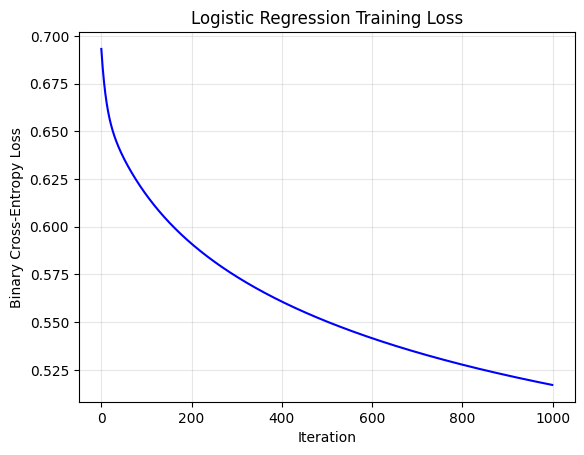

In [17]:
# Train logistic regression
lr_model = LogisticRegression()
lr_model.fit(X_train, Y_train)
lr_model.predict(X_test)

# Plot loss curve
plt.plot(range(len(lr_model.losses)), lr_model.losses, color='blue')
plt.title('Logistic Regression Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.show()

### Model 2: KNN from Scratch

In [18]:
# KNN from scratch
# Math: euclidean distance = sqrt(sum((x_i - x_j)^2)), prediction = majority vote of k nearest
class KNN:
    def __init__(self, neighbors=5):
        self.k = neighbors

    def fit(self, X, Y):
        self.X_train = np.array(X)
        self.Y_train = np.array(Y)

    def calculate_distance_from_a(self, a):
        return np.sqrt(np.sum((self.X_train - a) ** 2, axis=1))

    def predict_single(self, a):
        a = np.array(a)
        D = self.calculate_distance_from_a(a)
        K = np.argsort(D)[:self.k]
        k_labels = self.Y_train[K]
        # Majority vote among the k nearest neighbors
        return int(np.round(np.mean(k_labels)))

    def predict(self, X):
        X = np.array(X)
        return np.array([self.predict_single(x) for x in X])

In [19]:
# Train KNN
knn_model = KNN(neighbors=5)
knn_model.fit(X_train, Y_train)
knn_model.predict(X_test)

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0])

### Model 3: Decision Tree from Scratch

In [20]:
# Decision Tree from scratch
# Math: Gini impurity = 1 - sum(p_i^2), split on feature/threshold that maximizes information gain
class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def gini(self, y):
        """Gini impurity: measures how 'impure' a node is.
        Pure node (all same class) = 0, worst case (50/50) = 0.5"""
        if len(y) == 0:
            return 0
        p = np.mean(y)
        return 1 - p**2 - (1 - p)**2

    def best_split(self, X, y):
        """Try every feature and threshold, pick the one that reduces Gini the most."""
        best_gain, best_feature, best_threshold = -1, None, None
        parent_gini = self.gini(y)
        n = len(y)

        for col in range(X.shape[1]):
            thresholds = np.unique(X[:, col])
            # If too many unique values, sample 20 percentiles (speed up)
            if len(thresholds) > 20:
                thresholds = np.percentile(X[:, col], np.linspace(5, 95, 20))

            for t in thresholds:
                left_mask = X[:, col] <= t
                left_y = y[left_mask]
                right_y = y[~left_mask]

                if len(left_y) < 2 or len(right_y) < 2:
                    continue

                # Weighted average Gini of children
                weighted_gini = (len(left_y)/n) * self.gini(left_y) + (len(right_y)/n) * self.gini(right_y)
                gain = parent_gini - weighted_gini

                if gain > best_gain:
                    best_gain = gain
                    best_feature = col
                    best_threshold = t

        return best_feature, best_threshold, best_gain

    def build_tree(self, X, y, depth=0):
        """Recursively build the tree by finding the best split at each node."""
        # Stop if: max depth reached, too few samples, or all same class
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            return {'leaf': True, 'prediction': int(np.round(np.mean(y)))}

        feature, threshold, gain = self.best_split(X, y)

        if feature is None or gain <= 0:
            return {'leaf': True, 'prediction': int(np.round(np.mean(y)))}

        left_mask = X[:, feature] <= threshold
        return {
            'leaf': False,
            'feature': feature,
            'threshold': threshold,
            'left': self.build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self.build_tree(X[~left_mask], y[~left_mask], depth + 1),
        }

    def fit(self, X, Y):
        self.tree = self.build_tree(np.array(X), np.array(Y))

    def predict_single(self, x, node=None):
        """Walk down the tree until we hit a leaf."""
        if node is None:
            node = self.tree
        if node['leaf']:
            return node['prediction']
        if x[node['feature']] <= node['threshold']:
            return self.predict_single(x, node['left'])
        return self.predict_single(x, node['right'])

    def predict(self, X):
        return np.array([self.predict_single(x) for x in np.array(X)])

In [21]:
# Train Decision Tree
tree_model = DecisionTree(max_depth=6, min_samples_split=10)
tree_model.fit(X_train, Y_train)
tree_model.predict(X_test)[:10]

array([0, 0, 1, 1, 0, 1, 1, 0, 0, 0])

## Step 5: Evaluation (30 min) ⏱️

In [22]:
# Metrics from scratch
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    confusion = np.array([[TN, FP], [FN, TP]])
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'confusion': confusion}

print("compute_metrics() ready.")

compute_metrics() ready.


In [23]:
# Evaluate all 3 models on the test set
lr_preds   = lr_model.predict(X_test)
knn_preds  = knn_model.predict(X_test)
tree_preds = tree_model.predict(X_test)

results = {
    'Logistic Regression': compute_metrics(Y_test, lr_preds),
    'KNN (k=5)':           compute_metrics(Y_test, knn_preds),
    'Decision Tree':       compute_metrics(Y_test, tree_preds),
}

for name, m in results.items():
    print(f"\n{'='*40}")
    print(f" {name}")
    print(f"{'='*40}")
    print(f"  Accuracy:  {m['accuracy']:.4f}")
    print(f"  Precision: {m['precision']:.4f}")
    print(f"  Recall:    {m['recall']:.4f}")
    print(f"  F1-Score:  {m['f1']:.4f}")
    print(f"  Confusion Matrix:\n{m['confusion']}")


 Logistic Regression
  Accuracy:  0.7135
  Precision: 0.7059
  Recall:    0.3692
  F1-Score:  0.4848
  Confusion Matrix:
[[103  10]
 [ 41  24]]

 KNN (k=5)
  Accuracy:  0.7809
  Precision: 0.7167
  Recall:    0.6615
  F1-Score:  0.6880
  Confusion Matrix:
[[96 17]
 [22 43]]

 Decision Tree
  Accuracy:  0.8483
  Precision: 0.8065
  Recall:    0.7692
  F1-Score:  0.7874
  Confusion Matrix:
[[101  12]
 [ 15  50]]


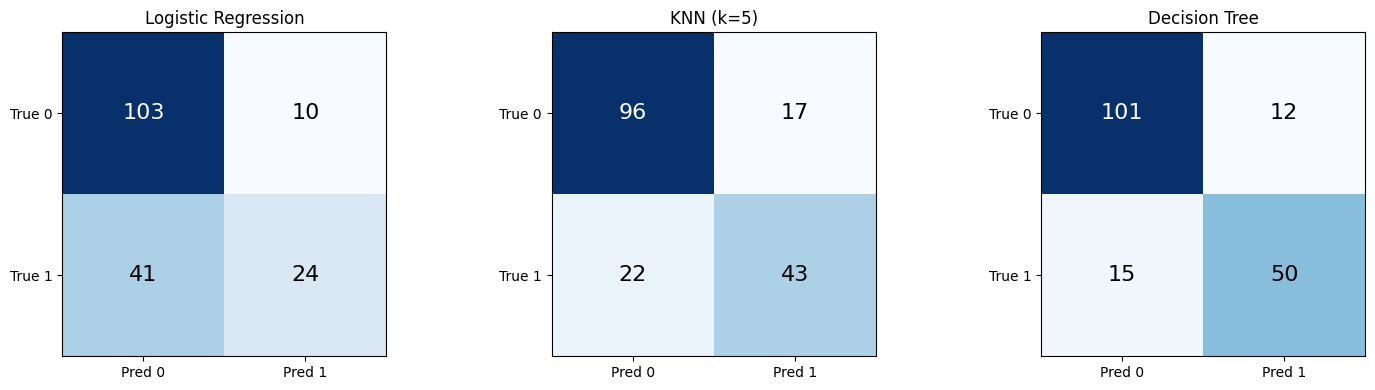

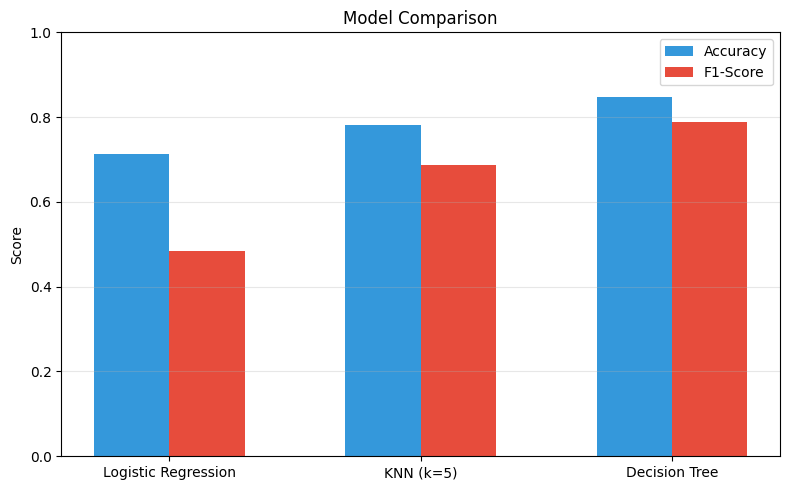

In [24]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_names = ['Logistic Regression', 'KNN (k=5)', 'Decision Tree']

for i, name in enumerate(model_names):
    cm = results[name]['confusion']
    axes[i].imshow(cm, cmap='Blues')
    axes[i].set_title(name)
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Pred 0', 'Pred 1'])
    axes[i].set_yticklabels(['True 0', 'True 1'])
    for row in range(2):
        for col in range(2):
            axes[i].text(col, row, str(cm[row, col]), ha='center', va='center',
                         color='white' if cm[row, col] > cm.max()/2 else 'black', fontsize=16)
plt.tight_layout()
plt.show()

# --- Grouped Bar Chart ---
x = np.arange(3)
accs = [results[n]['accuracy'] for n in model_names]
f1s  = [results[n]['f1'] for n in model_names]

plt.figure(figsize=(8, 5))
plt.bar(x - 0.15, accs, width=0.3, label='Accuracy', color='#3498db')
plt.bar(x + 0.15, f1s,  width=0.3, label='F1-Score', color='#e74c3c')
plt.xticks(x, model_names)
plt.ylabel('Score')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Write-up ⏱️

### Key Findings
1. **Decision Tree wins across all metrics**  (84.8% accuracy, 78.7% F1) Because it captures non-linear feature interactions (e.g., Sex + Pclass together) that linear models miss.
2. **Logistic Regression has high precision (70.6%) but terrible recall (36.9%)** It's  barely catching survivors. Only 1000 iterations with lr=0.01 isn't enough convergence for this feature set.
3. **KNN sits in the middle** (78.1% accuracy, 68.8% F1) and it was simple

### What I'd do with more time
- Tune hyperparameters: increase LR iterations/learning rate, try different k values for KNN, experiment with max_depth for Decision Tree
- Add L2 regularization to Logistic Regression to prevent overfitting
- Try k-fold cross-validation to get more reliable accuracy estimates instead of a single 80/20 split
- Engineer more features: extract titles from Name (Mr/Mrs/Miss), trying to use Cabin deck letter even if it sound very difficult !

### One thing I learned today
- There are many hidden things you only discover when you start from an empty page with no AI .
Building from scratch forces you to understand every single step of the algorithm.
I started with an empty page , did lot of veeeery wrong things then the ai oriented me , the final step was using ai to make it clean and better for future revision . It was fun !

### Where I got stuck
- Coding was the hardest part: variable naming collisions (model overwritten), KNN majority vote logic, getting the math right for gradients in Logistic Regression, and understanding when to use dot product vs element-wise multiply